In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('blinkit_multiclass.csv')
df.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
0,3,12669,9656,7561,214,2674,1338,2
1,3,7057,9810,9568,1762,3293,1776,2
2,3,6353,8808,7684,2405,3516,7844,2
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1


**Data Description**

|feature|Description|
|-|-|
|**Region**|where the store is located (1: Tier-1 city, 2: Tier-2 city, 3:Tier-3 city)|
|**Fresh**|purchase history of Fresh food|
|**Milk**|purchase history of milk product|
|**Grocery**|purchase history of Grocery|
|**Frozen**|purchase history of Frozen food|
|**Detergents_Paper**|purchase history of washing products|
|**Delicassen**|purchase history of imported products, cooked meat|
|**class**|Store catgeory based on demand on products|





<Axes: xlabel='class', ylabel='count'>

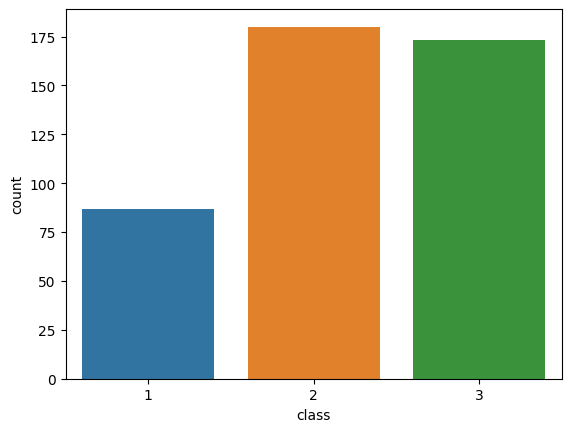

In [ ]:
import seaborn as sns
sns.countplot(data=df, x="class")

In [ ]:
X=df[['Region',	'Fresh',	'Milk',	'Grocery',	'Frozen',	'Detergents_Paper',	'Delicassen']].copy()
y=df[['class']].copy()

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# reducing features to just 2 features
pca = PCA(n_components=2)
print(X.shape)
X = pca.fit_transform(X)
print(X.shape)

(440, 7)
(440, 2)


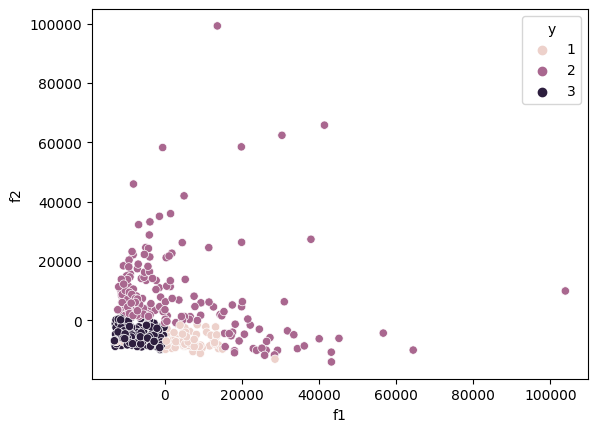

In [ ]:
df2 = pd.DataFrame(X, columns=['f1', 'f2'])
df2['y'] = y

sns.scatterplot(data= df2, x= 'f1',y = 'f2' , hue = 'y')
plt.show()

In [ ]:
## train test split

from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X,
                                                    y.values[:,0],
                                                    test_size=0.25, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val,
                                                    y_train_val,
                                                    test_size=0.25, random_state=42)

In [ ]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(247, 2) (247,)
(83, 2) (83,)
(110, 2) (110,)


In [ ]:
# standardisation
mu = X_train.mean(axis=0)
sig = X_train.std(axis=0)

In [ ]:
X_train = (X_train-mu)/sig
X_val = (X_val-mu)/sig
X_test = (X_test-mu)/sig

In [ ]:
## KNN Algo

def knn(X,Y,queryPoint,k=5):
    """Predict the class label for the query point"""
    # Euclidean Distance
    dist = np.sqrt(np.sum((queryPoint-X)**2,axis=1) )

    # Storing distance and Class labels together
    distances = [(dist[i],Y[i]) for i in range(len(dist)) ]
    # sort the distances
    distances = sorted(distances, key=lambda x:x[0])
    # Nearest/First K points
    distances = distances[:k]

    # print(f'k nearest neighbors with the distance and class label :{distances}')
    distances = np.array(distances)

    classes_counts = np.unique(distances[:,1],return_counts=True)
    #print(classes_counts)

    index = classes_counts[1].argmax()
    pred = classes_counts[0][index]

    return int(pred)

In [ ]:
## predicting
print(X_test[50])
print(knn(X_train, y_train, X_test[50]))

[0.12263833 1.24645031]
2


In [ ]:
print(y_test[50])

2


In [ ]:
y_pred = np.zeros(X_test.shape[0])

for i in range(X_test.shape[0]):
    y_pred[i] = knn(X_train, y_train, X_test[i])

print(f'Accuracy : ', round(100*(y_pred == y_test).sum()/y_pred.shape[0], 2))

Accuracy :  95.45


In [ ]:
# Hyper-parameter tuning
def give_me_accuracy(k):
    y_pred = []

    for Xq in X_test:
        p = knn(X_train, y_train, Xq, k = k)
        y_pred.append(p)

    y_pred = np.array(y_pred)

    acc = (y_pred == y_test).sum() / len(y_test)
    return acc.round(5)*100

In [ ]:
scores = []
k_values = []


for k in range(1, 15):
    k_values.append(k)
    score = give_me_accuracy(k)
    scores.append(score)

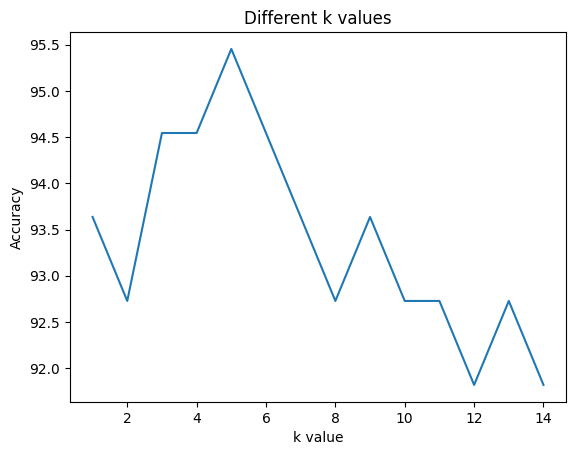

In [ ]:
plt.plot(k_values, scores)
plt.title("Different k values")
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
print(np.argmax(scores))
print("best k is", k_values[np.argmax(scores)])

4
best k is 5


In [ ]:
# Sklearn's KNN implementation
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5,metric='euclidean')
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [ ]:
y_pred = knn.predict(X_test)
knn.score(X_test, y_test)

0.9545454545454546

In [ ]:
x_q = [X_test[50]]
y_q = y_test[50]
print(x_q)
print(y_q)
print(knn.predict(x_q))
print(knn.predict_proba(x_q))
print(knn.kneighbors(x_q))

[array([0.12263833, 1.24645031])]
2
[2]
[[0. 1. 0.]]
(array([[0.18070887, 0.32677292, 0.39396904, 0.41363633, 0.53038291]]), array([[101, 176, 108,  30, 130]]))


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay(classification_report(y_test, y_pred))
plt.show()

              precision    recall  f1-score   support

           1       0.90      0.90      0.90        20
           2       0.98      0.94      0.96        47
           3       0.96      1.00      0.98        43

    accuracy                           0.95       110
   macro avg       0.94      0.95      0.94       110
weighted avg       0.95      0.95      0.95       110

